EXERCICE 1 : Descente de gradient "from scratch"
=================================================
Objectif : Implémenter une descente de gradient pour la régression linéaire,
visualiser la convergence, et comprendre l'impact du learning rate.

Ce que vous allez apprendre :
- Implémenter la descente de gradient pas à pas
- Visualiser la trajectoire dans l'espace des paramètres
- Diagnostiquer les problèmes de convergence (learning rate)
- Comparer avec la solution analytique (OLS)

Pré-requis : M03_F01, Bloc 1 de ce module
Temps estimé : 15 minutes

In [4]:
import numpy as np
import matplotlib.pyplot as plt

## 1. GÉNÉRER DES DONNÉES SYNTHÉTIQUES

In [5]:
# =============================================================
# 1. GÉNÉRER DES DONNÉES SYNTHÉTIQUES
# =============================================================
print("=" * 60)
print("EXERCICE 1 : Descente de gradient from scratch")
print("=" * 60)

np.random.seed(42)
n = 200
X_raw = np.random.uniform(0, 10, n)
y = 3.5 * X_raw + 7 + np.random.normal(0, 2, n)  # y = 3.5x + 7 + bruit

# Ajouter l'intercept (colonne de 1)
X = np.column_stack([np.ones(n), X_raw])  # Shape (n, 2) : [1, x]

print(f"Vraie relation : y = 3.5 * x + 7 + bruit")
print(f"Objectif : retrouver β₀ ≈ 7 et β₁ ≈ 3.5 par descente de gradient")

EXERCICE 1 : Descente de gradient from scratch
Vraie relation : y = 3.5 * x + 7 + bruit
Objectif : retrouver β₀ ≈ 7 et β₁ ≈ 3.5 par descente de gradient


In [16]:
# =============================================================
# 2. SOLUTION ANALYTIQUE (RÉFÉRENCE)
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 1 : Solution analytique (OLS)")
print("=" * 60)

# La solution analytique : β = (X^T X)^{-1} X^T y
beta_ols = np.linalg.inv(X.T @ X) @ X.T @ y
print(f"Solution OLS : β₀ = {beta_ols[0]:.4f}, β₁ = {beta_ols[1]:.4f}")


PARTIE 1 : Solution analytique (OLS)
Solution OLS : β₀ = 7.2104, β₁ = 3.4844


In [ ]:
# =============================================================
# 3. DESCENTE DE GRADIENT — À IMPLÉMENTER
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 2 : Descente de gradient")
print("=" * 60)

# TODO : Implémenter la descente de gradient pour la MSE
# Rappel de la formule de mise à jour :
#   β^{t+1} = β^{t} - η * gradient
# Avec gradient = -(1/n) * X^T @ (y - X @ β)

def gradient_descent(X, y, learning_rate=0.01, n_iterations=1000, tol=1e-6):
    """
    Descente de gradient pour la régression linéaire (MSE).
    
    Retourne :
    - beta : les paramètres finaux
    - history : liste des (beta, loss) à chaque itération
    """
    n, p = X.shape
    beta = np.zeros(p)  # Initialisation à zéro
    history = []
    
    for t in range(n_iterations):
        # TODO : Calculer les prédictions
        y_pred = None  # À compléter
        
        # TODO : Calculer la perte MSE
        loss = None  # À compléter
        
        # TODO : Calculer le gradient
        gradient = None  # À compléter
        
        # Stocker l'historique
        history.append((beta.copy(), loss))
        
        # TODO : Vérifier convergence (norme du gradient < tol)
        
        
        # TODO : Mettre à jour les paramètres
        beta = None  # À compléter
    
    return beta, history

# TODO : Exécuter avec learning_rate = 0.001
# beta_gd, history = gradient_descent(X, y, learning_rate=0.001, n_iterations=5000)
# print(f"Solution GD : β₀ = {beta_gd[0]:.4f}, β₁ = {beta_gd[1]:.4f}")
print("\n--- Learning rate = 0.001 ---")



PARTIE 2 : Descente de gradient

--- Learning rate = 0.001 ---
  Solution GD : β₀ = 5.4637, β₁ = 3.7501
  Erreur vs OLS : 1.766790



PARTIE 3 : Impact du learning rate
  η=0.0001 → 5000 iter, β₀=1.488, β₁=4.355
  η=0.001  → 5000 iter, β₀=5.464, β₁=3.750
  η=0.005  → 5000 iter, β₀=7.201, β₁=3.486

--- Learning rate trop grand (η=0.05) ---


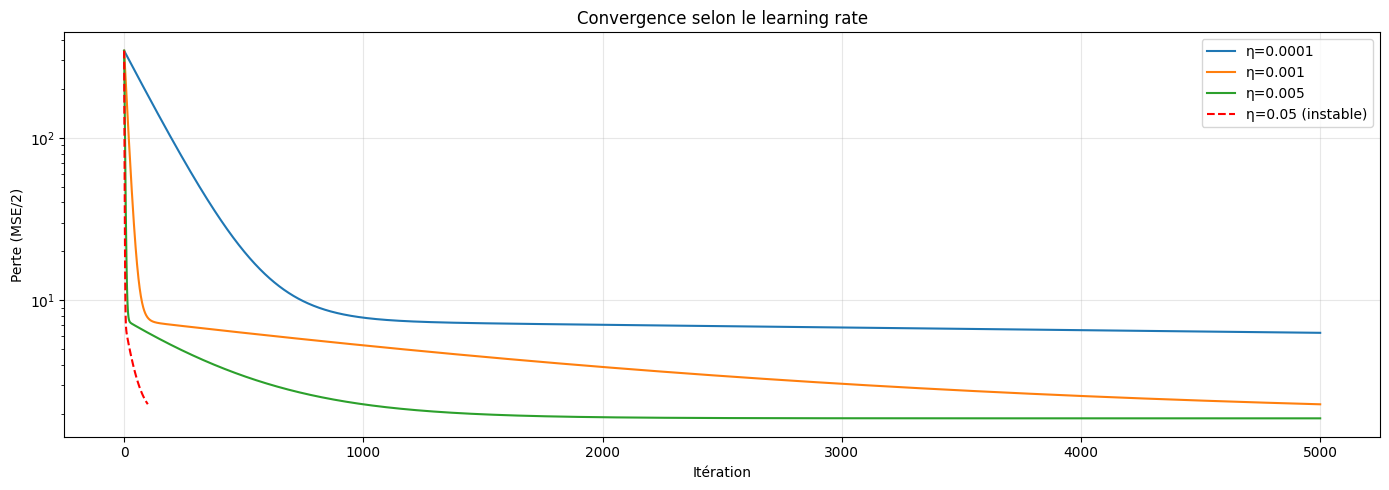

In [ ]:
# =============================================================
# 4. IMPACT DU LEARNING RATE
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 3 : Impact du learning rate")
print("=" * 60)

# TODO : Tester 3 learning rates différents et tracer les courbes de convergence
# learning_rates = [0.0001, 0.001, 0.01]
# Pour chaque LR, extraire l'historique des pertes et tracer loss vs iteration



# TODO : Un learning rate trop grand (0.1) — que se passe-t-il ?
# Indice : la perte explose (overflow) ou oscille





PARTIE 4 : Trajectoire dans l'espace des paramètres


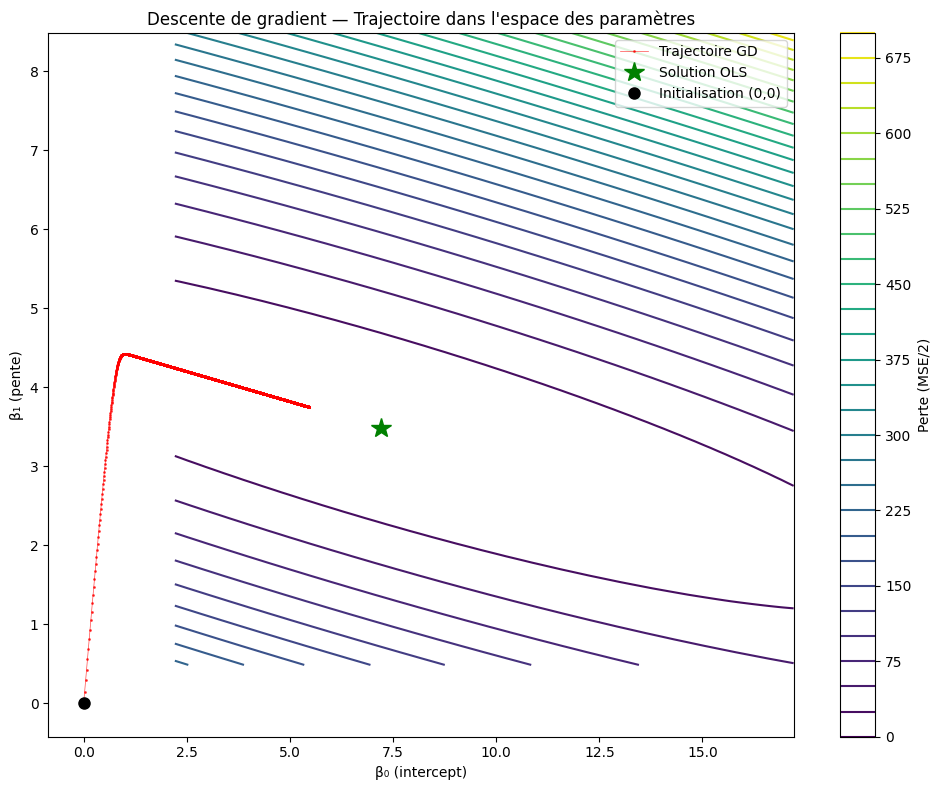

In [ ]:
# =============================================================
# 5. VISUALISATION DE LA TRAJECTOIRE
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 4 : Trajectoire dans l'espace des paramètres")
print("=" * 60)

# TODO : Tracer les courbes de niveau de la MSE en fonction de (β₀, β₁)
# et superposer la trajectoire de la descente de gradient
# Indice :
#   - Créer une grille de (β₀, β₁)
#   - Pour chaque point, calculer la MSE
#   - plt.contour() pour les courbes de niveau
#   - plt.plot() pour la trajectoire (extraite de history)



In [ ]:
# =============================================================
# 6. NORMALISATION ET CONVERGENCE
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 5 : Impact de la normalisation")
print("=" * 60)

# TODO : Normaliser X (StandardScaler), relancer la descente de gradient
# Observer : converge-t-on plus vite ?
# Pourquoi la normalisation aide-t-elle ?




PARTIE 5 : Impact de la normalisation
  Convergence à l'itération 1242
  Convergence à l'itération 3699
  Sans normalisation (η=0.001) : 5000 itérations, β = [5.46370911 3.75011159]
  Sans normalisation (η=0.01) : 3700 itérations, β = [7.21002784 3.48444275]
  Avec normalisation (η=0.01)  : 1243 itérations, β = [24.0749554  10.24939617]
  → La normalisation permet un LR plus grand et une convergence plus rapide

  Condition number (sans norm) : 124.5
  Condition number (avec norm) : 1.0
  → Un 'condition number' plus proche de 1 = convergence plus uniforme


## QUESTIONS DE RÉFLEXION

In [ ]:
# =============================================================
# QUESTIONS DE RÉFLEXION
# =============================================================
"""
1. Avec learning_rate=0.001 et 5000 itérations, êtes-vous proche de la 
   solution OLS ? Combien d'itérations faudrait-il pour une précision de 1e-6 ?

2. Que se passe-t-il avec learning_rate=0.1 ? Pouvez-vous expliquer 
   mathématiquement pourquoi ?
   (Indice : condition de convergence η < 2/λ_max(X^T X / n))

3. Pourquoi la normalisation des features accélère-t-elle la convergence ?
   (Indice : rapport entre les valeurs propres de X^T X)

4. Dans la pratique (sklearn), utilise-t-on vraiment la descente de gradient 
   pour la régression linéaire ? Si non, pourquoi existe-t-elle quand même ?

5. Quel est le lien entre cette descente de gradient et le Gradient Boosting 
   vu ce matin ? En quoi est-ce le "même" algorithme appliqué différemment ?
"""

'\n1. Avec learning_rate=0.001 et 5000 itérations, êtes-vous proche de la \n   solution OLS ? Combien d\'itérations faudrait-il pour une précision de 1e-6 ?\n\n2. Que se passe-t-il avec learning_rate=0.1 ? Pouvez-vous expliquer \n   mathématiquement pourquoi ?\n   (Indice : condition de convergence η < 2/λ_max(X^T X / n))\n\n3. Pourquoi la normalisation des features accélère-t-elle la convergence ?\n   (Indice : rapport entre les valeurs propres de X^T X)\n\n4. Dans la pratique (sklearn), utilise-t-on vraiment la descente de gradient \n   pour la régression linéaire ? Si non, pourquoi existe-t-elle quand même ?\n\n5. Quel est le lien entre cette descente de gradient et le Gradient Boosting \n   vu ce matin ? En quoi est-ce le "même" algorithme appliqué différemment ?\n'